In [1]:
import pandas as pd

# Define the PATHS dictionary
PATHS = {
    "gemma": {
        "phase": "../results/phase_transition_run04.csv",
        "arc":   "../results/arc_eval_gemma_run04_full.csv",
        "label": "Gemma-2-2B-IT",
        "tag": "(a)",
    },
    "llama1b": {
        "phase": "../results/phase_transition_data_llama_02.csv",
        "arc":   "../results/arc_eval_llama_run02_full.csv",
        "label": "Llama-3.2-1B-Instruct",
        "tag": "(b)",
    },
    "llama3b": {
        "phase": "../results/phase_transition_llama3b_01_with_disclaimers.csv",
        "arc":   "../results/arc_eval_llama3b_run01.csv",
        "label": "Llama-3.2-3B-Instruct",
        "tag": "(c)",
    },
    "llama8b": {
        "phase": "../results/phase_transition_llama8b_01.csv",
        "arc":   "../results/arc_eval_llama8b_01.csv",
        "label": "Llama-3.1-8B-Instruct",
        "tag": "(d)",
    },
}

# Function to read and print CSV contents
def print_csv_contents():
    for model, info in PATHS.items():
        print(f"\n=== Model: {info['label']} ({info['tag']}) ===")
        
        # Print contents of 'phase' CSV
        phase_file = info['phase']
        print(f"\nContents of phase file: {phase_file}")
        try:
            phase_df = pd.read_csv(phase_file)
            print(phase_df)
        except FileNotFoundError:
            print(f"Error: File {phase_file} not found.")
        except Exception as e:
            print(f"Error reading {phase_file}: {e}")

        # Print contents of 'arc' CSV
        arc_file = info['arc']
        print(f"\nContents of arc file: {arc_file}")
        try:
            arc_df = pd.read_csv(arc_file)
            print(arc_df)
        except FileNotFoundError:
            print(f"Error: File {arc_file} not found.")
        except Exception as e:
            print(f"Error reading {arc_file}: {e}")

# Run the function
print_csv_contents()


=== Model: Gemma-2-2B-IT ((a)) ===

Contents of phase file: ../results/phase_transition_run04.csv
    checkpoint_step  persona_vector_similarity  persona_logprob_margin  \
0                 0                   0.493401                1.596040   
1                 1                   0.501871                1.321798   
2                 2                   0.502297                1.319919   
3                 3                   0.502715                1.317871   
4                 5                   0.503534                1.310493   
5                 7                   0.504443                1.301161   
6                10                   0.505403                1.286728   
7                12                   0.505374                1.283941   
8                15                   0.504537                1.291222   
9                18                   0.502990                1.316620   
10               20                   0.501374                1.346226   
11           

Gemma-2-2B-IT: knees={'onset': None, 'collapse': 30, 'piecewise': 20} -> using piecewise: 20
Llama-3.2-1B-Instruct: knees={'onset': None, 'collapse': 15, 'piecewise': 18} -> using collapse: 15
Llama-3.2-3B-Instruct: knees={'onset': 12, 'collapse': 18, 'piecewise': 18} -> using piecewise: 18
Llama-3.1-8B-Instruct: knees={'onset': None, 'collapse': None, 'piecewise': None} -> using piecewise: None

--- Generated Table 1 ---


,model,knee_step,n_pre,ARC_pre,n_post,ARC_post,Δ(post–pre),U,p_U,"ρ(ARC,cos)",p_cos,"ρ(ARC,ref)",p_ref
0,Gemma-2-2B-IT,20.0,11,72.82,7,61.32,-11.50pp,19.0,0.168717,0.038537,8.832555e-01,0.783295,0.000200
1,Llama-3.2-1B-Instruct,15.0,9,33.89,10,27.79,-6.10pp,87.5,0.000582,0.966553,1.766367e-11,0.622347,0.004434
2,Llama-3.2-3B-Instruct,18.0,10,61.67,5,60.60,-1.07pp,38.5,0.106543,0.351164,1.993491e-01,-0.316092,0.251073
3,Llama-3.1-8B-Instruct,NaN,0,NaN,0,NaN,N/A,NaN,NaN,-0.205196,7.405819e-01,-0.286770,0.639942



Wrote Table 1 CSV:  ../results/figures/table_arc_pre_post_stats.csv
Wrote Table 1 LaTeX:../results/figures/table_arc_pre_post_stats.tex

--- Generating Figure 1 Panels ---


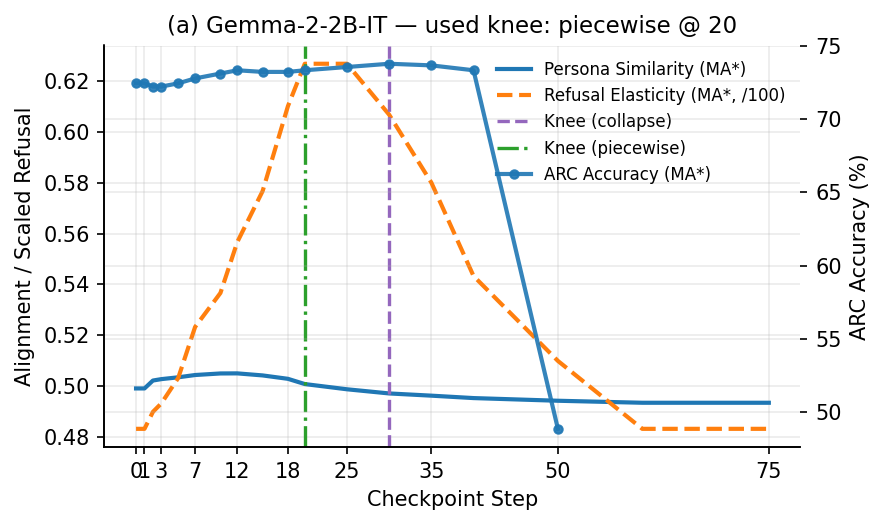

Wrote: ../results/figures/fig_identity_arc_gemma.png | ../results/figures/fig_identity_arc_gemma.pdf


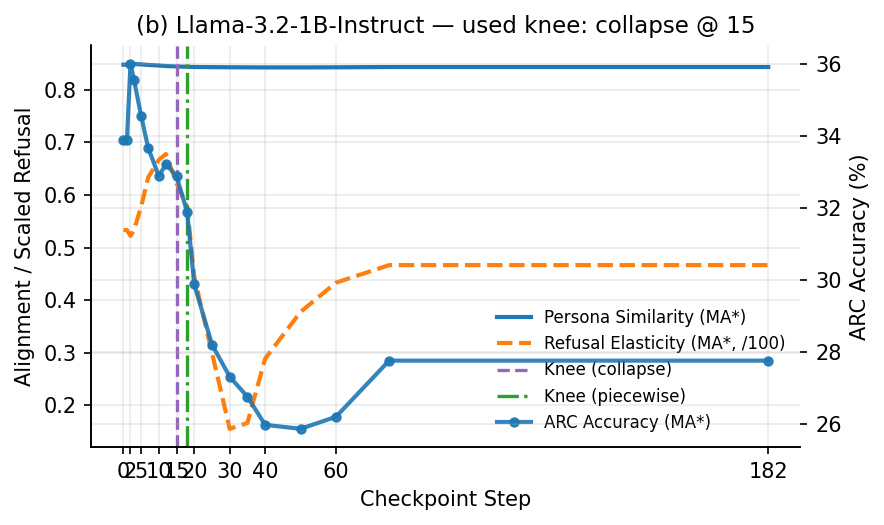

Wrote: ../results/figures/fig_identity_arc_llama1b.png | ../results/figures/fig_identity_arc_llama1b.pdf


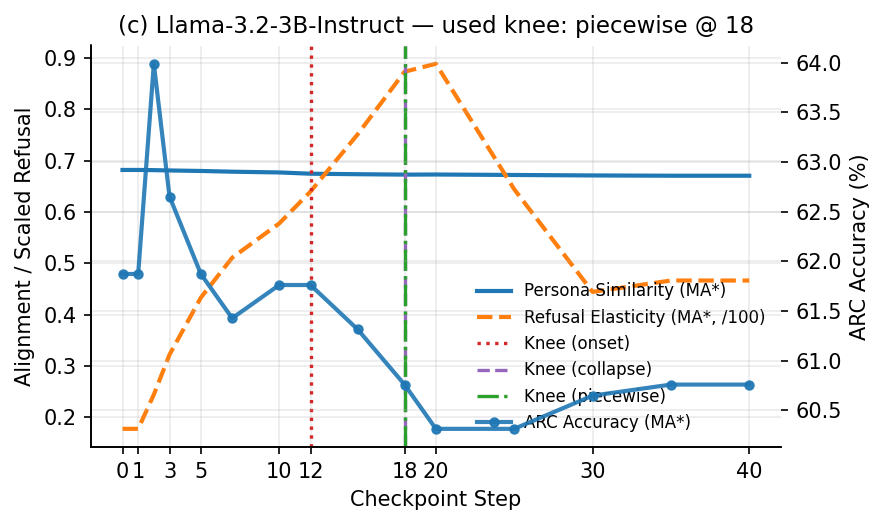

Wrote: ../results/figures/fig_identity_arc_llama3b.png | ../results/figures/fig_identity_arc_llama3b.pdf


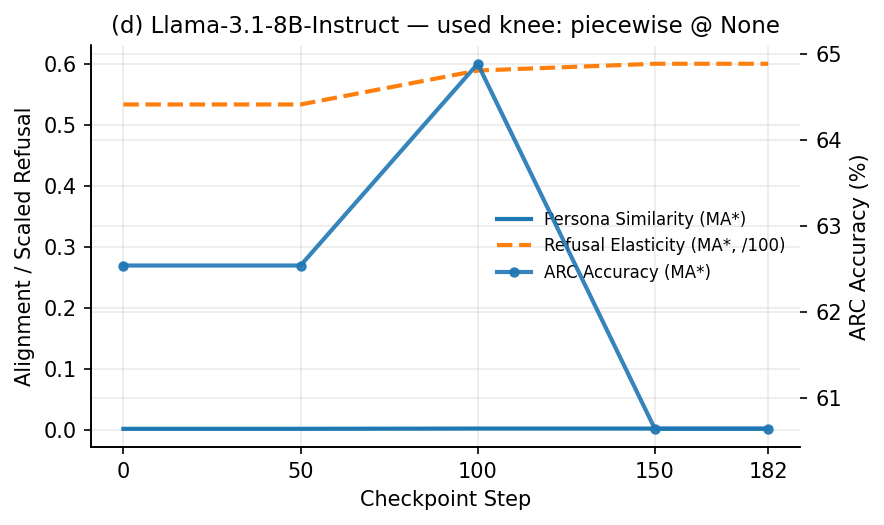

Wrote: ../results/figures/fig_identity_arc_llama8b.png | ../results/figures/fig_identity_arc_llama8b.pdf


In [19]:
# Final Analysis: Phase Transition Plots and Statistics
#
# Loads per-checkpoint phase metrics + ARC accuracy, computes robust "knees",
# produces Table 1 stats, and exports Figure 1 panels for all runs.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, spearmanr

# --- Matplotlib styling ---
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# --- Paths to your data files ---
# (phase = from 03_analyze..., arc = from 05_eval...)
PATHS = {
    "gemma": {
        "phase": "../results/phase_transition_run04.csv",
        "arc":   "../results/arc_eval_gemma_run04_full.csv",
        "label": "Gemma-2-2B-IT",
        "tag": "(a)",
    },
    "llama1b": {
        "phase": "../results/phase_transition_data_llama_02.csv",
        "arc":   "../results/arc_eval_llama_run02_full.csv",
        "label": "Llama-3.2-1B-Instruct",
        "tag": "(b)",
    },
    "llama3b": {
        "phase": "../results/phase_transition_llama3b_01_with_disclaimers.csv",
        "arc":   "../results/arc_eval_llama3b_run01.csv",
        "label": "Llama-3.2-3B-Instruct",
        "tag": "(c)",
    },
    # NEW: Llama-8B
    "llama8b": {
        "phase": "../results/phase_transition_llama8b_01.csv",
        "arc":   "../results/arc_eval_llama8b_01.csv",
        "label": "Llama-3.1-8B-Instruct",
        "tag": "(d)",
    },
}

OUT_DIR = "../results/figures"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------- 1) Utilities: smoothing, knees, loading ----------------

def ma_centered(x, w=5):
    """
    Centered moving average with edge-fix.
    If the series is short, shrink window to largest odd <= len(x) (min 3).
    """
    x = np.asarray(x, float)
    n = len(x)
    if n == 0:
        return x
    W = min(w, n if n % 2 == 1 else n - 1)
    if W < 3:
        return x
    pad = W // 2
    kern = np.ones(W, dtype=float) / W
    z = np.convolve(x, kern, mode="same")
    # edge correction
    z[:pad]  = np.mean(x[:W])
    z[-pad:] = np.mean(x[-W:])
    return z

def _two_seg_rss(x, y, k):
    """RSS of two independent linear fits split at index k (split between k and k+1)."""
    n = len(x)
    if k < 1 or k > n-2:
        return np.inf
    xl, yl = x[:k+1], y[:k+1]
    a1, b1 = np.polyfit(xl, yl, 1)
    r1 = yl - (a1*xl + b1)
    xr, yr = x[k+1:], y[k+1:]
    a2, b2 = np.polyfit(xr, yr, 1)
    r2 = yr - (a2*xr + b2)
    return float(np.sum(r1**2) + np.sum(r2**2))

def find_knees(checkpoint_steps, refusal_pct, onset_pp=10.0, guard=2):
    """
    Returns (knee_onset_step, knee_collapse_step, knee_piecewise_step)
      - onset: steepest positive slope if total rise >= onset_pp
      - collapse: most negative curvature after early peak
      - piecewise: breakpoint minimizing 2-segment RSS
    All on adaptively-smoothed refusal (%).
    """
    x  = np.asarray(checkpoint_steps, int)
    y0 = np.asarray(refusal_pct, float)
    n  = len(y0)
    if n < 5:
        return None, None, None

    # adaptive MA
    y = ma_centered(y0, 5)

    # Onset
    dy = np.diff(y)
    onset_ix = None
    if (y[-1] - y[0]) >= onset_pp:
        i0, i1 = guard, (n-1) - guard
        if i1 > i0:
            local = dy[i0:i1]
            j = np.argmax(local)
            onset_ix = i0 + j + 1

    # Collapse (after early peak)
    d2 = y[2:] - 2*y[1:-1] + y[:-2]
    collapse_ix = None
    early_end = max(guard+2, int(0.5*n))
    peak_ix = np.argmax(y[:early_end]) if early_end > 0 else np.argmax(y)
    lo = max(peak_ix, guard+1)
    hi = (n-1) - guard
    if hi - lo >= 1:
        sl = d2[(lo-1):(hi-1)]
        j = np.argmin(sl)
        collapse_ix = (lo-1) + j + 1

    # Piecewise (RSS)
    pw_ix = None
    best_rss = np.inf
    for k in range(guard+1, n-guard-1):
        rss = _two_seg_rss(x, y, k)
        if rss < best_rss:
            best_rss, pw_ix = rss, k

    knee_on   = int(x[onset_ix])   if onset_ix   is not None else None
    knee_col  = int(x[collapse_ix]) if collapse_ix is not None else None
    knee_pw   = int(x[pw_ix])      if pw_ix      is not None else None
    return knee_on, knee_col, knee_pw

def nice_step_ticks(x, max_ticks=8):
    x = np.asarray(x, int)
    if len(x) <= max_ticks:
        return x
    idx = np.linspace(0, len(x)-1, num=max_ticks, dtype=int)
    return np.unique(x[idx])

def load_and_join(phase_csv, arc_csv):
    """Load phase + ARC data; merge on checkpoint_step; compute smoothed series."""
    try:
        phase = pd.read_csv(phase_csv)
    except FileNotFoundError:
        print(f"[warn] Phase not found: {phase_csv}")
        return None
    try:
        arc = pd.read_csv(arc_csv)
    except FileNotFoundError:
        print(f"[warn] ARC not found: {arc_csv} (continuing without ARC)")
        arc = pd.DataFrame(columns=["checkpoint_step"])

    arc_acc_col = "arc_challenge_acc"
    if arc_acc_col not in arc.columns:
        candidates = [c for c in arc.columns if ("arc" in c.lower() and "acc" in c.lower())]
        if candidates:
            arc_acc_col = candidates[0]
        else:
            arc[arc_acc_col] = np.nan

    if "checkpoint_step" not in arc.columns:
        arc["checkpoint_step"] = phase["checkpoint_step"]

    merged = pd.merge(phase, arc[["checkpoint_step", arc_acc_col]], on="checkpoint_step", how="left")
    merged = merged.sort_values("checkpoint_step").reset_index(drop=True)
    merged = merged.rename(columns={arc_acc_col: "arc_challenge_acc"})

    # Smoothed series
    merged["cos_ma3"]     = ma_centered(merged["persona_vector_similarity"], 3)
    merged["refusal_ma3"] = ma_centered(merged["refusal_elasticity"], 3)
    if "arc_challenge_acc" in merged.columns and not merged["arc_challenge_acc"].isnull().all():
        merged["arc_ma3"] = ma_centered(merged["arc_challenge_acc"], 3)
    else:
        merged["arc_ma3"] = np.nan
    return merged

# ---------------- 2) Load runs + compute knees ----------------

runs = {}
for key, cfg in PATHS.items():
    df = load_and_join(cfg["phase"], cfg["arc"])
    if df is not None:
        runs[key] = df

# Which knee to prefer when summarizing (fallbacks applied if None)
KNEE_USE = {
    "gemma":   "piecewise",  # clean monotone rise; piecewise is consistent
    "llama1b": "collapse",   # volatile; collapse captures the crash best
    "llama3b": "piecewise",  # flat-ish; RSS breakpoint is most stable
    "llama8b": "piecewise",  # few points; use piecewise
}

knees_all, knees = {}, {}
for key, df in runs.items():
    k_on, k_col, k_pw = find_knees(df["checkpoint_step"], df["refusal_elasticity"], onset_pp=10.0, guard=2)
    knees_all[key] = {"onset": k_on, "collapse": k_col, "piecewise": k_pw}
    use = KNEE_USE.get(key, "piecewise")
    chosen = knees_all[key][use]
    if chosen is None:
        for alt in ["piecewise", "onset", "collapse"]:
            if knees_all[key][alt] is not None:
                use, chosen = alt, knees_all[key][alt]
                break
    knees[key] = chosen
    print(f"{PATHS[key]['label']}: knees={knees_all[key]} -> using {use}: {chosen}")

# ---------------- 3) Table 1 stats (pre/post wrt knee) ----------------

def pre_post(df, knee_step):
    if knee_step is None or pd.isna(knee_step):
        return pd.DataFrame(), pd.DataFrame()
    return df[df["checkpoint_step"] <= knee_step], df[df["checkpoint_step"] > knee_step]

rows = []
for key, df in runs.items():
    knee = knees[key]
    label = PATHS[key]["label"]
    pre, post = pre_post(df, knee)

    arc_pre  = pre["arc_challenge_acc"].mean() if len(pre) > 0 else np.nan
    arc_post = post["arc_challenge_acc"].mean() if len(post) > 0 else np.nan
    delta    = arc_post - arc_pre

    if len(pre) >= 1 and len(post) >= 1 and not pre["arc_challenge_acc"].isnull().all():
        U, pU = mannwhitneyu(pre["arc_challenge_acc"].dropna(),
                             post["arc_challenge_acc"].dropna(),
                             alternative="two-sided")
    else:
        U, pU = np.nan, np.nan

    df_corr = df[["arc_challenge_acc", "persona_vector_similarity", "refusal_elasticity"]].dropna()
    if len(df_corr) > 1:
        rho_cos, p_cos = spearmanr(df_corr["arc_challenge_acc"], df_corr["persona_vector_similarity"])
        rho_ref, p_ref = spearmanr(df_corr["arc_challenge_acc"], df_corr["refusal_elasticity"])
    else:
        rho_cos, p_cos, rho_ref, p_ref = np.nan, np.nan, np.nan, np.nan

    rows.append({
        "model": label,
        "knee_step": knee,
        "n_pre": len(pre),
        "ARC_pre": round(arc_pre, 2) if pd.notna(arc_pre) else np.nan,
        "n_post": len(post),
        "ARC_post": round(arc_post, 2) if pd.notna(arc_post) else np.nan,
        "Δ(post–pre)": f"{delta:+.2f}pp" if pd.notna(delta) else "N/A",
        "U": (None if np.isnan(U) else round(float(U), 1)),
        "p_U": (None if np.isnan(pU) else float(pU)),
        "ρ(ARC,cos)": (None if np.isnan(rho_cos) else float(rho_cos)),
        "p_cos": (None if np.isnan(p_cos) else float(p_cos)),
        "ρ(ARC,ref)": (None if np.isnan(rho_ref) else float(rho_ref)),
        "p_ref": (None if np.isnan(p_ref) else float(p_ref)),
    })

table1 = pd.DataFrame(rows)
print("\n--- Generated Table 1 ---")
display(table1)

# Save Table 1 (CSV + LaTeX)
table_path_csv = os.path.join(OUT_DIR, "table_arc_pre_post_stats.csv")
table_path_tex = os.path.join(OUT_DIR, "table_arc_pre_post_stats.tex")
table1.to_csv(table_path_csv, index=False)
latex = table1.to_latex(index=False, float_format="%.4g", na_rep='N/A', escape=False)
with open(table_path_tex, "w") as f:
    f.write(latex)
print(f"\nWrote Table 1 CSV:  {table_path_csv}")
print(f"Wrote Table 1 LaTeX:{table_path_tex}")

# ---------------- 4) Figure 1 panels ----------------

def plot_model_panel(df, label, knees_dict, used_key, tag, save_base):
    df = df.sort_values("checkpoint_step")
    x  = df["checkpoint_step"].to_numpy()

    fig, ax1 = plt.subplots(figsize=(6.0, 3.6))
    ax1.plot(x, df["cos_ma3"], lw=2, label="Persona Similarity (MA*)")
    ax1.plot(x, df["refusal_ma3"]/100.0, "--", lw=2, label="Refusal Elasticity (MA*, /100)")

    # vertical candidates
    k_on, k_col, k_pw = knees_dict["onset"], knees_dict["collapse"], knees_dict["piecewise"]
    if k_on is not None:  ax1.axvline(k_on,  color="#d62728", ls=":",  lw=1.6, label="Knee (onset)")
    if k_col is not None: ax1.axvline(k_col, color="#9467bd", ls="--", lw=1.6, label="Knee (collapse)")
    if k_pw is not None:  ax1.axvline(k_pw,  color="#2ca02c", ls="-.",  lw=1.6, label="Knee (piecewise)")

    ax1.set_xlabel("Checkpoint Step")
    ax1.set_ylabel("Alignment / Scaled Refusal")

    ticks = x if len(x) <= 10 else x[np.linspace(0, len(x)-1, 10, dtype=int)]
    ax1.set_xticks(ticks)
    ax1.set_xticklabels([str(t) for t in ticks])

    ax2 = ax1.twinx()
    if "arc_ma3" in df.columns and not df["arc_ma3"].isnull().all():
        ax2.plot(x, df["arc_ma3"], marker="o", ms=4, lw=2, alpha=0.9, label="ARC Accuracy (MA*)")
        ax2.set_ylabel("ARC Accuracy (%)")

    # merged legend (dedupe)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    seen, H, L = set(), [], []
    for h, l in list(zip(h1,l1)) + list(zip(h2,l2)):
        if l in seen:
            continue
        seen.add(l); H.append(h); L.append(l)
    ax1.legend(H, L, loc="best", fontsize=8, frameon=False)

    used_step = knees_dict.get(used_key, None)
    ax1.set_title(f"{tag} {label} — used knee: {used_key} @ {used_step}", fontsize=11)

    plt.tight_layout()
    fig_png = f"{save_base}.png"
    fig_pdf = f"{save_base}.pdf"
    fig.savefig(fig_png, bbox_inches="tight")
    fig.savefig(fig_pdf, bbox_inches="tight")
    plt.show()
    print("Wrote:", fig_png, "|", fig_pdf)

print("\n--- Generating Figure 1 Panels ---")
for key, df in runs.items():
    label = PATHS[key]["label"]
    tag   = PATHS[key]["tag"]
    base  = os.path.join(OUT_DIR, f"fig_identity_arc_{key}")
    plot_model_panel(df, label, knees_all[key], KNEE_USE[key], tag, base)



--- Summary Table (No Knees) ---


,Model,n_ckpts,ARC_mean,ARC_std,PersonaSim_mean,Refusal_mean,ΔARC(pp),ΔPersonaSim,ΔRefusal(pp),"ρ(ARC,cos)","p(ARC,cos)","ρ(ARC,ref)","p(ARC,ref)","ρ(cos,ref)","p(cos,ref)"
0,Gemma-2-2B-IT,18,73.04,0.60,0.4998,53.9,-0.33,+0.0000,+0.0,-0.157,5.612266e-01,0.760,0.000634,0.058,0.831928
1,Llama-3.2-1B-Instruct,19,30.68,3.76,0.8448,47.7,+0.00,+0.0000,+0.0,0.967,1.766367e-11,0.622,0.004434,0.652,0.002504
2,Llama-3.2-3B-Instruct,15,61.32,1.95,0.6762,52.1,+4.01,-0.0120,+66.7,0.351,1.993491e-01,-0.316,0.251073,-0.573,0.025411
3,Llama-3.1-8B-Instruct,5,63.55,8.44,0.0022,56.0,+0.00,+0.0014,+16.7,-0.205,7.405819e-01,-0.287,0.639942,0.447,0.450185


Wrote: ../results/figures/table_no_knees_summary.csv
Wrote: ../results/figures/table_no_knees_summary.tex

--- Generating Panels (No Knees) ---


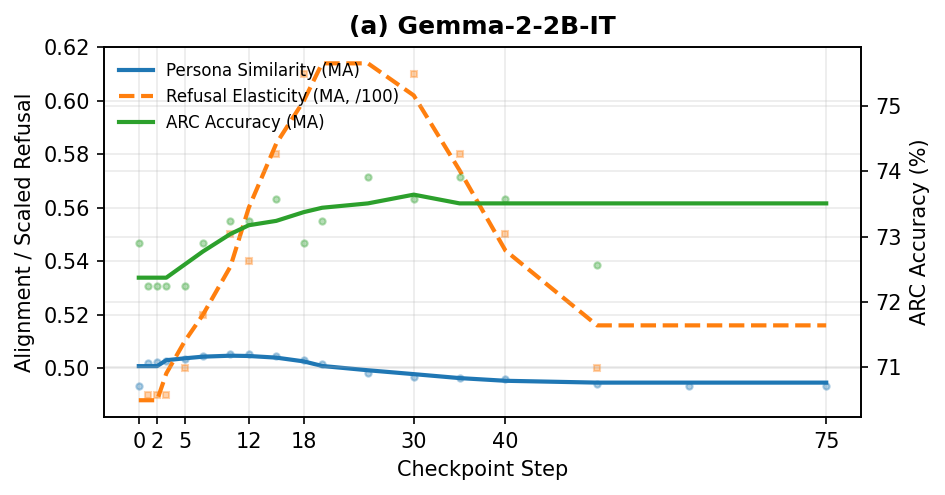

Wrote: ../results/figures/fig_identity_arc_noknee_gemma.png | ../results/figures/fig_identity_arc_noknee_gemma.pdf


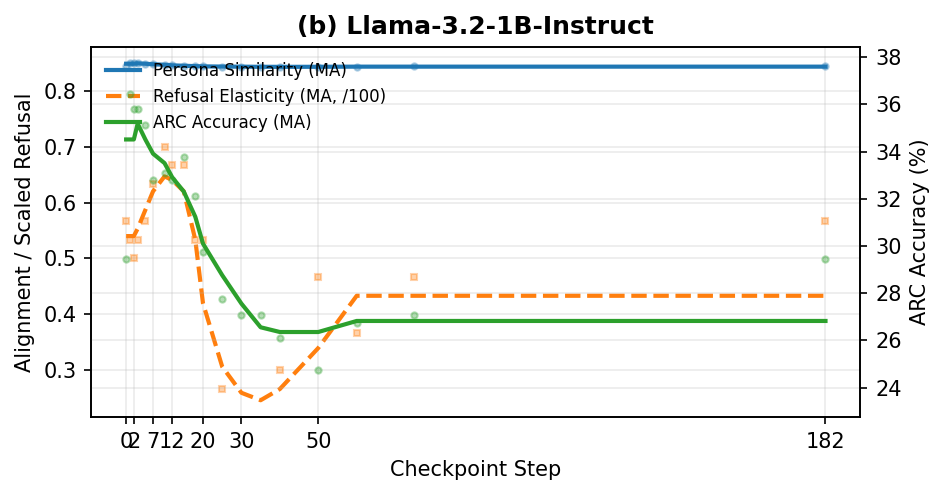

Wrote: ../results/figures/fig_identity_arc_noknee_llama1b.png | ../results/figures/fig_identity_arc_noknee_llama1b.pdf


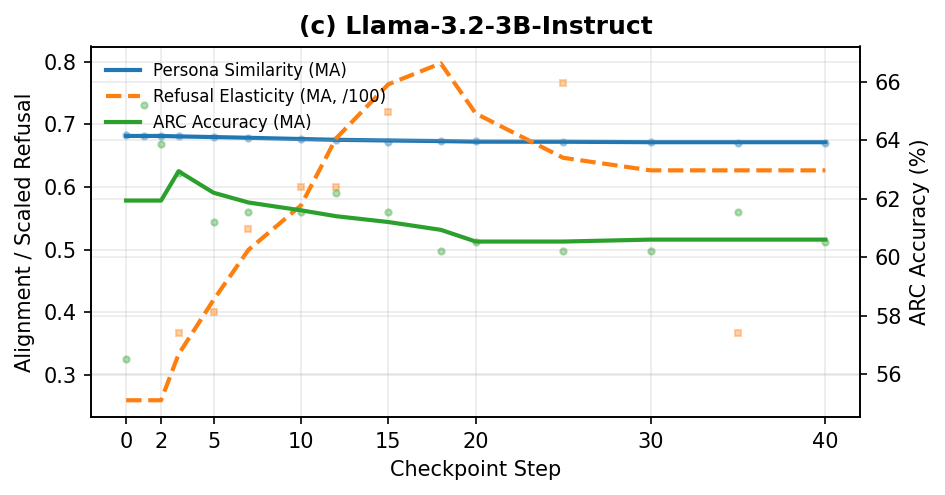

Wrote: ../results/figures/fig_identity_arc_noknee_llama3b.png | ../results/figures/fig_identity_arc_noknee_llama3b.pdf


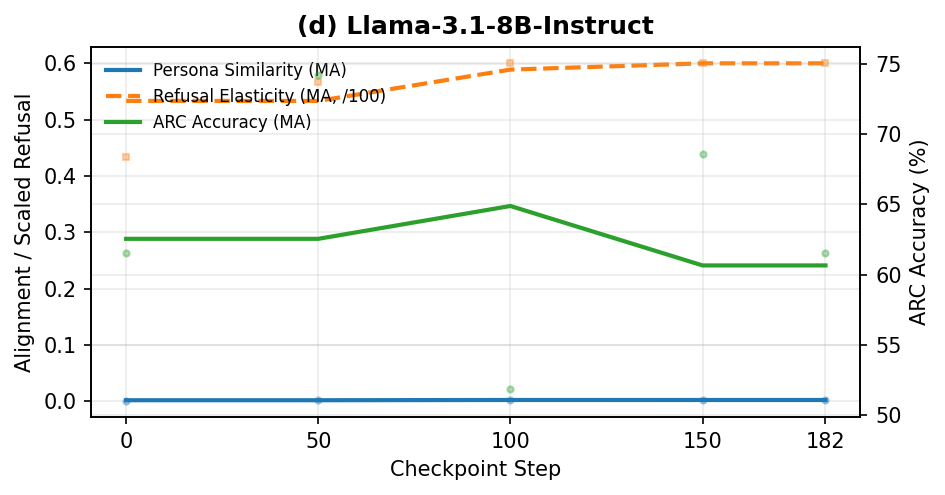

Wrote: ../results/figures/fig_identity_arc_noknee_llama8b.png | ../results/figures/fig_identity_arc_noknee_llama8b.pdf


In [2]:
# Final Analysis (No Knees): Phase Dynamics & Summary Stats
#
# - Loads per-checkpoint phase metrics + ARC accuracy
# - Plots persona similarity, refusal elasticity, ARC (no knee lines)
# - Produces a summary table (means, deltas, Spearman correlations)
# - Saves figures and LaTeX/CSV table

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Safe display (works in/without notebooks)
try:
    from IPython.display import display
except Exception:
    def display(x):  # fallback
        print(x)

# ---------- Style ----------
plt.rcParams.update({
    "figure.dpi": 150,
    # "axes.spines.top": False,   # not a valid rcParam; handled per-axes if needed
    # "axes.spines.right": False, # not a valid rcParam
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# ---------- Paths ----------
PATHS = {
    "gemma": {
        "phase": "../results/phase_transition_run04.csv",
        "arc":   "../results/arc_eval_gemma_run04_full.csv",
        "label": "Gemma-2-2B-IT",
        "tag": "(a)",
    },
    "llama1b": {
        "phase": "../results/phase_transition_data_llama_02.csv",
        "arc":   "../results/arc_eval_llama_run02_full.csv",
        "label": "Llama-3.2-1B-Instruct",
        "tag": "(b)",
    },
    "llama3b": {
        "phase": "../results/phase_transition_llama3b_01_with_disclaimers.csv",
        "arc":   "../results/arc_eval_llama3b_run01.csv",
        "label": "Llama-3.2-3B-Instruct",
        "tag": "(c)",
    },
    "llama8b": {
        "phase": "../results/phase_transition_llama8b_01.csv",
        "arc":   "../results/arc_eval_llama8b_01.csv",
        "label": "Llama-3.1-8B-Instruct",
        "tag": "(d)",
    },
}

OUT_DIR = "../results/figures"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Helpers ----------
def ma_centered(x, w=5):
    """Adaptive centered MA with edge-fix; shrink window for short series."""
    x = np.asarray(x, float)
    n = len(x)
    if n == 0:
        return x
    W = min(w, n if n % 2 == 1 else n - 1)
    if W < 3:
        return x
    pad = W // 2
    z = np.convolve(x, np.ones(W)/W, mode="same")
    z[:pad]  = np.mean(x[:W])
    z[-pad:] = np.mean(x[-W:])
    return z

def _adaptive_ma(x, w_long=5, w_short=3, short_n=7):
    x = np.asarray(x, float)
    n = len(x)
    if n <= 1:
        return x
    W = w_short if n <= short_n else w_long
    W = max(3, min(W, n if n % 2 == 1 else n - 1))
    pad = W // 2
    z = np.convolve(x, np.ones(W)/W, mode="same")
    z[:pad]  = np.mean(x[:W])
    z[-pad:] = np.mean(x[-W:])
    return z

# alias to match downstream calls (fixes NameError)
ma_adaptive = _adaptive_ma

def load_and_join(phase_csv, arc_csv):
    phase = pd.read_csv(phase_csv)
    arc   = pd.read_csv(arc_csv)

    arc_acc_col = "arc_challenge_acc"
    if arc_acc_col not in arc.columns:
        cand = [c for c in arc.columns if ("arc" in c.lower() and "acc" in c.lower())]
        if cand:
            arc_acc_col = cand[0]
        else:
            arc[arc_acc_col] = np.nan

    if "checkpoint_step" not in arc.columns:
        # best-effort align with phase steps
        arc["checkpoint_step"] = phase["checkpoint_step"]

    df = pd.merge(phase, arc[["checkpoint_step", arc_acc_col]], on="checkpoint_step", how="left")
    df = df.sort_values("checkpoint_step").reset_index(drop=True)
    df = df.rename(columns={arc_acc_col: "arc_challenge_acc"})

    # OPTIONAL: mask obviously corrupt ARC values (e.g., failed evals)
    if "arc_challenge_acc" in df.columns:
        df.loc[df["arc_challenge_acc"] < 1, "arc_challenge_acc"] = np.nan

    # Adaptive smoothing
    df["cos_ma"]     = ma_adaptive(df["persona_vector_similarity"])
    df["refusal_ma"] = ma_adaptive(df["refusal_elasticity"])
    df["arc_ma"]     = ma_adaptive(df["arc_challenge_acc"]) if "arc_challenge_acc" in df.columns else np.nan
    return df

def nice_ticks(x, max_ticks=10):
    x = np.asarray(x, int)
    if len(x) <= max_ticks:
        return x
    idx = np.linspace(0, len(x)-1, num=max_ticks, dtype=int)
    return np.unique(x[idx])

def plot_model_panel(df, label, tag, save_base, arc_ffill=True):
    """Clean, uncluttered panel without knees."""
    df = df.sort_values("checkpoint_step").copy()
    x  = df["checkpoint_step"].to_numpy()

    # Build smoothed series
    cos_ma  = _adaptive_ma(df["persona_vector_similarity"])
    ref_ma  = _adaptive_ma(df["refusal_elasticity"]) / 100.0
    arc_raw = df["arc_challenge_acc"] if "arc_challenge_acc" in df.columns else pd.Series([np.nan]*len(df))
    arc_ma  = _adaptive_ma(arc_raw)
    if arc_ffill:
        arc_ma = pd.Series(arc_ma).ffill().to_numpy()

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(6.4, 3.4))

    # Persona similarity (left axis)
    ax1.plot(x, df["persona_vector_similarity"], "o", ms=3, alpha=0.35, color="C0", label="_nolegend_")
    ax1.plot(x, cos_ma, "-", lw=2, color="C0", label="Persona Similarity (MA)")

    # Refusal (scaled to 0..1 on left axis)
    ax1.plot(x, (df["refusal_elasticity"]/100.0), "s", ms=3, alpha=0.35, color="C1", label="_nolegend_")
    ax1.plot(x, ref_ma, "--", lw=2, color="C1", label="Refusal Elasticity (MA, /100)")

    ax1.set_xlabel("Checkpoint Step")
    ax1.set_ylabel("Alignment / Scaled Refusal")

    # Left y-range: pad by 5% to avoid crowding
    left_vals = np.concatenate([cos_ma, ref_ma])
    ylo, yhi = np.nanmin(left_vals), np.nanmax(left_vals)
    pad = 0.05 * max(1e-6, (yhi - ylo))
    ax1.set_ylim(ylo - pad, yhi + pad)

    # Ticks: show ≤8 x-ticks and keep actual step numbers
    ticks = x if len(x) <= 8 else x[np.linspace(0, len(x)-1, 8, dtype=int)]
    ax1.set_xticks(ticks)
    ax1.set_xticklabels([str(t) for t in ticks])

    # ARC on right axis (raw points faint + MA line)
    ax2 = ax1.twinx()
    if not np.all(np.isnan(arc_raw)):
        ax2.plot(x, arc_raw, "o", ms=3, alpha=0.35, color="C2", label="_nolegend_")
        ax2.plot(x, arc_ma, "-", lw=2, color="C2", label="ARC Accuracy (MA)")
        ax2.set_ylabel("ARC Accuracy (%)")
        # Tighten to ARC range ±2pp
        a_lo = np.nanmin(arc_raw)
        a_hi = np.nanmax(arc_raw)
        if np.isfinite(a_lo) and np.isfinite(a_hi) and a_hi > a_lo:
            pad_pp = max(2.0, 0.05*(a_hi - a_lo))
            ax2.set_ylim(a_lo - pad_pp, a_hi + pad_pp)

    # Merge legends (only MA series are labeled)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    H, L, seen = [], [], set()
    for h, l in list(zip(h1, l1)) + list(zip(h2, l2)):
        if l == "_nolegend_" or l in seen:
            continue
        seen.add(l); H.append(h); L.append(l)
    ax1.legend(H, L, loc="upper left", fontsize=8, frameon=False)

    # Title and layout
    ax1.set_title(f"{tag} {label}", fontsize=12, weight="bold")
    fig.tight_layout()

    # Save
    png = f"{save_base}.png"; pdf = f"{save_base}.pdf"
    fig.savefig(png, bbox_inches="tight"); fig.savefig(pdf, bbox_inches="tight")
    plt.show()
    print("Wrote:", png, "|", pdf)

def plot_panel(df, label, tag, save_base):
    df = df.sort_values("checkpoint_step")
    x  = df["checkpoint_step"].to_numpy()

    fig, ax1 = plt.subplots(figsize=(6.6, 3.6))

    # Persona sim (raw + MA)
    ax1.plot(x, df["persona_vector_similarity"], "o", ms=4, alpha=0.6, label="Persona Similarity (raw)")
    ax1.plot(x, df["cos_ma"], "-", lw=2, label="Persona Similarity (MA)")

    # Refusal (raw + MA), scaled to 0..1 on left axis
    ax1.plot(x, df["refusal_elasticity"]/100.0, "s", ms=4, alpha=0.6, label="Refusal Elasticity (raw, /100)")
    ax1.plot(x, df["refusal_ma"]/100.0, "--", lw=2, label="Refusal Elasticity (MA, /100)")

    ax1.set_xlabel("Checkpoint Step")
    ax1.set_ylabel("Alignment / Scaled Refusal")
    # show actual steps (subset if many)
    ticks = x if len(x) <= 10 else x[np.linspace(0, len(x)-1, 10, dtype=int)]
    ax1.set_xticks(ticks)
    ax1.set_xticklabels([str(t) for t in ticks])

    # ARC on right axis (raw + MA), with tighter y-lims
    ax2 = ax1.twinx()
    if "arc_challenge_acc" in df.columns and not pd.isna(df["arc_challenge_acc"]).all():
        ax2.plot(x, df["arc_challenge_acc"], "o", ms=4, alpha=0.6, label="ARC Accuracy (raw)")
        ax2.plot(x, df["arc_ma"], "-", lw=2, label="ARC Accuracy (MA)")
        ax2.set_ylabel("ARC Accuracy (%)")
        arc_min = np.nanmin(df["arc_challenge_acc"])
        arc_max = np.nanmax(df["arc_challenge_acc"])
        if np.isfinite(arc_min) and np.isfinite(arc_max) and arc_max > arc_min:
            pad = max(2.0, 0.05*(arc_max - arc_min))
            ax2.set_ylim(arc_min - pad, arc_max + pad)

    # Merge legends
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    seen, H, L = set(), [], []
    for h, l in list(zip(h1, l1)) + list(zip(h2, l2)):
        if l in seen:
            continue
        seen.add(l); H.append(h); L.append(l)
    ax1.legend(H, L, loc="best", fontsize=8, frameon=False)

    ax1.set_title(f"{tag} {label}", fontsize=12, fontweight="bold")
    plt.tight_layout()

    fig_png = f"{save_base}.png"
    fig_pdf = f"{save_base}.pdf"
    fig.savefig(fig_png, bbox_inches="tight"); fig.savefig(fig_pdf, bbox_inches="tight")
    plt.show()
    print("Wrote:", fig_png, "|", fig_pdf)

# ---------- 1) Load all runs ----------
runs = {}
for key, cfg in PATHS.items():
    df = load_and_join(cfg["phase"], cfg["arc"])
    if df is not None:
        runs[key] = df

# ---------- 2) Summary table (no knees) ----------
rows = []
for key, df in runs.items():
    label = PATHS[key]["label"]
    n = len(df)

    # overall means
    arc_mean = df["arc_challenge_acc"].mean()
    arc_std  = df["arc_challenge_acc"].std(ddof=1)
    cos_mean = df["persona_vector_similarity"].mean()
    ref_mean = df["refusal_elasticity"].mean()

    # start/end deltas (trend sense)
    def _delta(col):
        s = df[col].dropna()
        return (s.iloc[-1] - s.iloc[0]) if len(s) >= 2 else np.nan
    d_arc = _delta("arc_challenge_acc")
    d_cos = _delta("persona_vector_similarity")
    d_ref = _delta("refusal_elasticity")

    # correlations
    sub = df[["arc_challenge_acc", "persona_vector_similarity", "refusal_elasticity"]].dropna()
    if len(sub) >= 3:
        rho_arc_cos, p_arc_cos = spearmanr(sub["arc_challenge_acc"], sub["persona_vector_similarity"])
        rho_arc_ref, p_arc_ref = spearmanr(sub["arc_challenge_acc"], sub["refusal_elasticity"])
        rho_cos_ref, p_cos_ref = spearmanr(sub["persona_vector_similarity"], sub["refusal_elasticity"])
    else:
        rho_arc_cos = p_arc_cos = rho_arc_ref = p_arc_ref = rho_cos_ref = p_cos_ref = np.nan

    rows.append({
        "Model": label,
        "n_ckpts": n,
        "ARC_mean": None if pd.isna(arc_mean) else round(float(arc_mean), 2),
        "ARC_std":  None if pd.isna(arc_std)  else round(float(arc_std), 2),
        "PersonaSim_mean": None if pd.isna(cos_mean) else round(float(cos_mean), 4),
        "Refusal_mean":    None if pd.isna(ref_mean) else round(float(ref_mean), 1),
        "ΔARC(pp)": None if pd.isna(d_arc) else f"{d_arc:+.2f}",
        "ΔPersonaSim": None if pd.isna(d_cos) else f"{d_cos:+.4f}",
        "ΔRefusal(pp)": None if pd.isna(d_ref) else f"{d_ref:+.1f}",
        "ρ(ARC,cos)": None if pd.isna(rho_arc_cos) else round(float(rho_arc_cos), 3),
        "p(ARC,cos)": None if pd.isna(p_arc_cos)  else float(p_arc_cos),
        "ρ(ARC,ref)": None if pd.isna(rho_arc_ref) else round(float(rho_arc_ref), 3),
        "p(ARC,ref)": None if pd.isna(p_arc_ref)  else float(p_arc_ref),
        "ρ(cos,ref)": None if pd.isna(rho_cos_ref) else round(float(rho_cos_ref), 3),
        "p(cos,ref)": None if pd.isna(p_cos_ref)  else float(p_cos_ref),
    })

table_no_knees = pd.DataFrame(rows)
print("\n--- Summary Table (No Knees) ---")
display(table_no_knees)

# Save table
os.makedirs(OUT_DIR, exist_ok=True)
csv_path = os.path.join(OUT_DIR, "table_no_knees_summary.csv")
tex_path = os.path.join(OUT_DIR, "table_no_knees_summary.tex")
table_no_knees.to_csv(csv_path, index=False)
with open(tex_path, "w") as f:
    f.write(table_no_knees.to_latex(index=False, float_format="%.4g", na_rep="N/A", escape=False))
print("Wrote:", csv_path)
print("Wrote:", tex_path)

# ---------- 3) Figure panels (no knees) ----------
print("\n--- Generating Panels (No Knees) ---")
for key, df in runs.items():
    label = PATHS[key]["label"]
    tag   = PATHS[key]["tag"]
    base  = os.path.join(OUT_DIR, f"fig_identity_arc_noknee_{key}")
    plot_model_panel(df, label, tag, base)
